In [76]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

In [ ]:
def detect_and_match_features(img1, img2):
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)
    if des1 is None or des2 is None:
        return 0, None, None
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)
    good = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good.append(m)
    if len(good) > 10:
        img1_out = img1.copy()
        img2_out = img2.copy()
        if len(img1_out.shape) == 2:
            img1_out = cv2.cvtColor(img1_out, cv2.COLOR_GRAY2BGR)
        if len(img2_out.shape) == 2:
            img2_out = cv2.cvtColor(img2_out, cv2.COLOR_GRAY2BGR)

        for m in good:
            pt1 = tuple(map(int, kp1[m.queryIdx].pt))
            pt2 = tuple(map(int, kp2[m.trainIdx].pt))
            color = (random.randint(0,255),random.randint(0,255),random.randint(0,255))
            cv2.circle(img1_out, pt1, 3, color, -1)
            cv2.circle(img2_out, pt2, 3, color, -1)

        return 1, img1_out, img2_out

    else:
        return 0, None, None

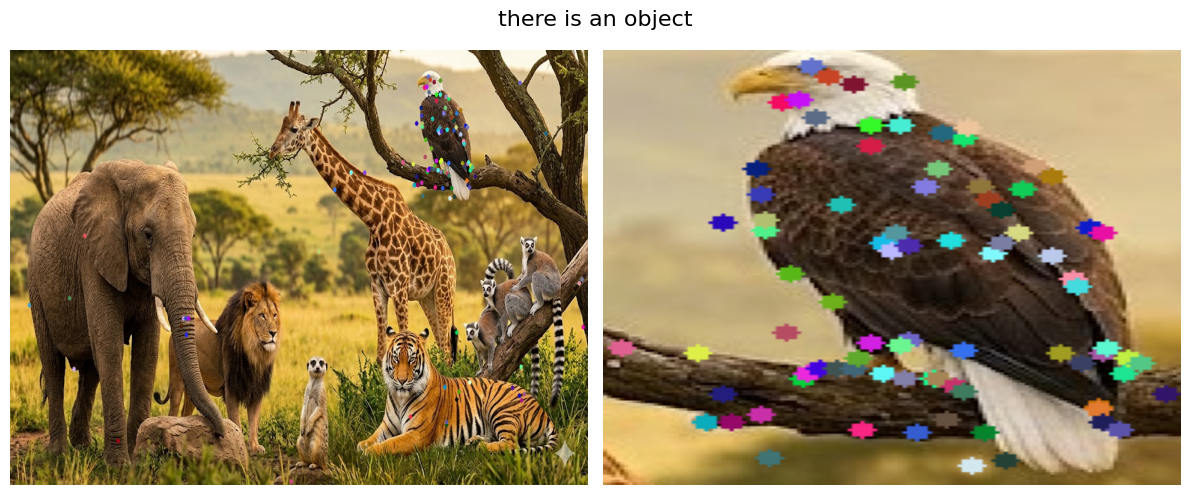

In [78]:
a = cv2.imread(r"D:\computer vision\test1.jpg") 
b = cv2.imread(r"D:\computer vision\test2.jpg")
B,x,y=detect_and_match_features(a,b)
if(B==1):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(x, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.gca().set_aspect('auto')
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(y, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.gca().set_aspect('auto')
    plt.suptitle("there is an object",fontsize=16)
    plt.tight_layout()
else:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(a, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.gca().set_aspect('auto')
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(b, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.gca().set_aspect('auto')
    plt.suptitle("there is no common object",fontsize=16)
    plt.tight_layout()